# Notebook for constructing age models for the North Shore Volcanics Southwest Sequence

In [12]:
using Pkg
Pkg.activate("../")
using Chron
using Plots, DelimitedFiles
using DataFrames, CSV
using Statistics, StatsBase

include("MCR_age_models.jl")

  Activating project at `~/Github/APWP_StratModels/code`


plot_posterior_paths (generic function with 1 method)

## North Shore Volcanics Southwest Sequence



In [13]:
NSVG_SW_Name = ("Top of Ely's Peak basalts", "40th Ave E Icelandite", "Two Harbors Icelandite", "Palisade Rhyolite", "Silver Bay Intrusion") # Et cetera
NSVG_SW_Age           = [ 1099, 1096.75, 1096.18, 1093.94, 1091.61] # Measured ages
NSVG_SW_Age_sigma     = [ 1/2,   0.28/2,  0.32/2,  0.28/2,  0.14/2] # Measured 1-σ uncertainties
NSVG_SW_Height        = [ 370,     2000,  6215,      7980,  8645] # Depths below surface should be negative
NSVG_SW_Age_Sidedness = [-1, 0, 0, 0, 1] # Sidedness (zeros by default: geochron constraints are two-sided). Use -1 for a maximum age and +1 for a minimum age, 0 for two-sided

NSVG_SW_Path = "../../data/age_models_output/NSVG_SW" # Where do you want output files to be stored

# construct the section (ChronAgeData object)
NSVG_SW_section = make_ChronAgeData(NSVG_SW_Name, NSVG_SW_Age, NSVG_SW_Age_sigma, NSVG_SW_Height, NSVG_SW_Age_Sidedness, NSVG_SW_Path, Age_Unit="Ma", Height_Unit="m")

ChronAgeData{5}(("Top of Ely's Peak basalts", "40th Ave E Icelandite", "Two Harbors Icelandite", "Palisade Rhyolite", "Silver Bay Intrusion"), [370.0, 2000.0, 6215.0, 7980.0, 8645.0], [0.01, 0.01, 0.01, 0.01, 0.01], [1099.0, 1096.75, 1096.18, 1093.94, 1091.61], [0.5, 0.14, 0.16, 0.14, 0.07], [NaN, NaN, NaN, NaN, NaN], [NaN, NaN, NaN, NaN, NaN], [NaN, NaN, NaN, NaN, NaN], [NaN, NaN, NaN, NaN, NaN], [-1.0, 0.0, 0.0, 0.0, 1.0], [0.0, 0.0, 0.0, 0.0, 0.0], [#undef, #undef, #undef, #undef, #undef], (:Chronometer, :Chronometer, :Chronometer, :Chronometer, :Chronometer), [NaN NaN … NaN NaN; NaN NaN … NaN NaN; … ; NaN NaN … NaN NaN; NaN NaN … NaN NaN], "../../data/age_models_output/NSVG_SW", 2, "Ma", "m", :cdf)

In [14]:
NSVG_SW_age_model_config, NSVG_SW_age_model_mdl, NSVG_SW_age_model_agedist, NSVG_SW_age_model_lldist = run_age_model(NSVG_SW_section, 10, 0.20, 1000, save_results=false, plot_results=false)

┌ Info: Generating stratigraphic age-depth model...
└ @ Chron /Users/yimingzhang/.julia/packages/Chron/zKIt8/src/StratMetropolis.jl:28
┌ Info: Burn-in: 1159000 steps
└ @ Chron /Users/yimingzhang/.julia/packages/Chron/zKIt8/src/StratMetropolis.jl:626
Burn-in... 100%|█████████████████████████████████████████| Time: 0:00:00
┌ Info: Collecting sieved stationary distribution: 1159000 steps
└ @ Chron /Users/yimingzhang/.julia/packages/Chron/zKIt8/src/StratMetropolis.jl:689
Collecting... 100%|██████████████████████████████████████| Time: 0:00:00


(StratAgeModelConfiguration(10.0, 1159000, 1000, 1159, 0.2), StratAgeModel([370.0, 380.0, 390.0, 400.0, 410.0, 420.0, 430.0, 440.0, 450.0, 460.0  …  8550.0, 8560.0, 8570.0, 8580.0, 8590.0, 8600.0, 8610.0, 8620.0, 8630.0, 8640.0], [1098.3570736833008, 1098.3471894792556, 1098.336997525703, 1098.3296762857276, 1098.319222952192, 1098.3108244746675, 1098.3002460278244, 1098.29133292486, 1098.2809252268291, 1098.2720572622015  …  1093.0394842452902, 1093.0247176825212, 1093.0116378200285, 1092.9944985803122, 1092.9790634344215, 1092.9603741563124, 1092.9440355950053, 1092.9249642803254, 1092.9076351057586, 1092.8928784793134], [0.5000968752681006, 0.5015846130499172, 0.5040086600978259, 0.5047383286864725, 0.5087442394956242, 0.5078163258566966, 0.5042753494927651, 0.504699473978667, 0.5049540661526866, 0.5046787063710573  …  0.4987831980895269, 0.4978622047818486, 0.5028543774435766, 0.5088745654744526, 0.5106900298888806, 0.5145729820992646, 0.5152241185067059, 0.5205755783309587, 0.5242

### posterior summary age model

In [15]:
function plot_age_model(section, mdl; save_figure=false)
    # Plot results (mean and 95% confidence interval for both model and data)
    hdl = plot([mdl.Age_025CI; reverse(mdl.Age_975CI)],[mdl.Height; reverse(mdl.Height)], fill=(round(Int,minimum(mdl.Height)),0.5,:grey), linecolor=:grey, label="model")
    plot!(hdl, mdl.Age, mdl.Height, linecolor=:grey, label="", fg_color_legend=:white) # Center line
    t = section.Age_Sidedness .== 0 # Two-sided constraints (plot in black)
    any(t) && plot!(hdl, section.Age[t], section.Height[t], xerror=2*section.Age_sigma[t],label="data",seriestype=:scatter,color=:black)
    t = section.Age_Sidedness .== 1 # Minimum ages (plot in cyan)
    any(t) && plot!(hdl, section.Age[t], section.Height[t], xerror=(2*section.Age_sigma[t],zeros(count(t))),label="", seriestype=:scatter,color=:dodgerblue,msc=:dodgerblue)
    # # any(t) && zip(section.Age[t], section.Age[t].+nanmean(section.Age_sigma[t])*4, section.Height[t]) .|> x-> plot!([x[1],x[2]],[x[3],x[3]], arrow=true, label="", color=:cyan)
    t = section.Age_Sidedness .== -1 # Maximum ages (plot in orange)
    any(t) && plot!(hdl, section.Age[t], section.Height[t], xerror=(zeros(count(t)),2*section.Age_sigma[t]),label="",seriestype=:scatter,color=:orange,msc=:orange)
    # # any(t) && zip(section.Age[t], section.Age[t].-nanmean(section.Age_sigma[t])*4, section.Height[t]) .|> x-> plot!([x[1],x[2]],[x[3],x[3]], arrow=true, label="", color=:orange)
    plot!(hdl, xlabel="Age ($(section.Age_Unit))", ylabel="Height ($(section.Height_Unit))", framestyle=:box)
    # reverse the x axis 
    plot!(hdl, xflip=true)
    # set y axis tick font size 
    plot!(hdl, ytickfont=10, xtickfont=10)
    # put the legend at the bottom right
    plot!(size=(300, 1000), legend=:bottomright, legendfontsize=9, xrotation=45)
    if save_figure
        savefig(hdl,section.Path*"AgeDepthModel.pdf")
    end
    return hdl
end

plot_age_model (generic function with 1 method)

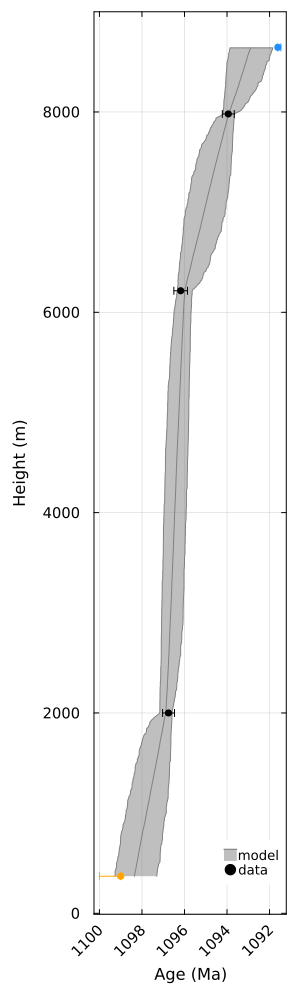

In [16]:
NSVG_SW_age_model = plot_age_model(NSVG_SW_section, NSVG_SW_age_model_mdl, save_figure=false)
plot!(ylim=(-10, 9000), left_margin = 12Plots.mm)
savefig(NSVG_SW_age_model, NSVG_SW_section.Path*"_AgeDepthModel.pdf")
display(NSVG_SW_age_model)

### example posterior accumulation models

  0.003420 seconds (17.00 k allocations: 20.096 MiB)


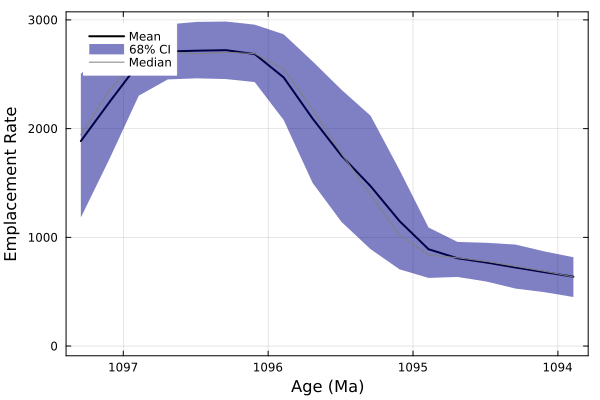

In [18]:
plot_accumulation_model(NSVG_SW_section, NSVG_SW_age_model_config, NSVG_SW_age_model_mdl, NSVG_SW_age_model_agedist, save_figure=false)

### example posterior age models

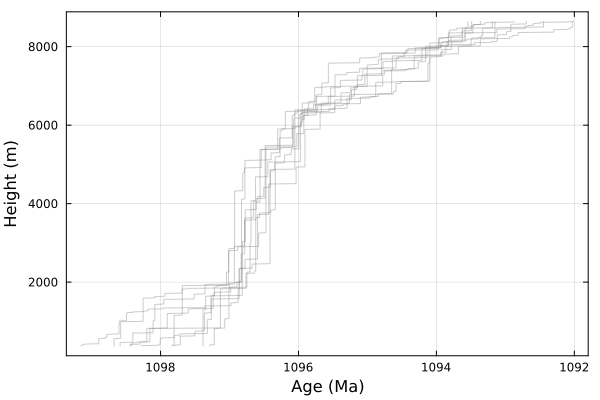

In [19]:
plot_posterior_paths(NSVG_SW_section, NSVG_SW_age_model_agedist, NSVG_SW_age_model_mdl)

## save the age models to a file

In [20]:
NSVG_SW_age_model_agedist

828×1000 Matrix{Float64}:
 1098.3   1098.81  1098.05  1098.4   …  1099.0   1097.6   1097.74  1098.02
 1098.3   1098.81  1098.05  1098.4      1099.0   1097.6   1097.74  1097.44
 1098.3   1098.81  1098.05  1098.4      1099.0   1097.6   1097.74  1097.44
 1098.3   1098.81  1098.05  1098.4      1099.0   1097.6   1097.74  1097.44
 1098.3   1098.81  1098.05  1098.4      1099.0   1097.36  1097.74  1097.44
 1098.3   1098.81  1098.05  1098.4   …  1099.0   1097.36  1097.74  1097.44
 1098.3   1098.81  1098.05  1097.8      1099.0   1097.36  1097.74  1097.44
 1098.3   1098.81  1098.05  1097.8      1098.85  1097.36  1097.74  1097.44
 1098.3   1098.81  1098.05  1097.8      1098.85  1097.36  1097.74  1097.44
 1098.3   1098.81  1098.05  1097.8      1098.85  1097.36  1097.74  1097.44
    ⋮                                ⋱                             
 1092.96  1092.39  1093.6   1093.65     1093.46  1093.94  1092.25  1092.17
 1092.96  1092.39  1093.6   1093.65  …  1093.46  1093.94  1092.25  1092.17
 1092.

In [22]:
# use the mdl.height as index, agedist as the data
NSVG_SW_age_models_df = DataFrame(hcat(NSVG_SW_age_model_mdl.Height, NSVG_SW_age_model_agedist), :auto)
# rename the first three columns to be site, height
rename!(NSVG_SW_age_models_df, Dict(:x1 => "height"))
NSVG_SW_age_models_df

Row,height,x2,x3,x4,x5,x6,x7,x8,x9,x10,x11,x12,x13,x14,x15,x16,x17,x18,x19,x20,x21,x22,x23,x24,x25,x26,x27,x28,x29,x30,x31,x32,x33,x34,x35,x36,x37,x38,x39,x40,x41,x42,x43,x44,x45,x46,x47,x48,x49,x50,x51,x52,x53,x54,x55,x56,x57,x58,x59,x60,x61,x62,x63,x64,x65,x66,x67,x68,x69,x70,x71,x72,x73,x74,x75,x76,x77,x78,x79,x80,x81,x82,x83,x84,x85,x86,x87,x88,x89,x90,x91,x92,x93,x94,x95,x96,x97,x98,x99,x100,⋯
,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,⋯
1,370.0,1098.3,1098.81,1098.05,1098.4,1098.59,1098.1,1098.66,1098.44,1098.95,1098.85,1098.94,1097.7,1097.93,1099.1,1098.02,1098.01,1099.05,1098.82,1098.03,1098.6,1098.13,1097.73,1098.9,1098.14,1098.87,1097.93,1098.61,1098.87,1098.94,1099.09,1098.58,1097.93,1097.96,1098.37,1097.96,1098.48,1098.69,1098.42,1097.76,1098.71,1098.41,1098.13,1098.16,1097.62,1098.18,1099.25,1098.48,1097.85,1098.04,1097.35,1098.08,1099.06,1097.95,1097.36,1098.04,1098.61,1097.24,1098.33,1098.58,1098.5,1098.38,1098.23,1098.15,1098.72,1098.82,1098.95,1098.63,1098.56,1098.0,1098.67,1098.26,1098.36,1097.96,1097.09,1098.24,1098.65,1098.52,1099.43,1098.84,1098.39,1098.19,1098.06,1098.22,1098.43,1098.97,1096.95,1098.85,1097.82,1098.27,1098.26,1098.43,1098.17,1098.87,1099.02,1099.02,1098.39,1098.6,1098.58,1098.5,⋯
2,380.0,1098.3,1098.81,1098.05,1098.4,1098.59,1098.1,1098.66,1098.44,1098.95,1098.85,1098.94,1097.7,1097.93,1099.1,1098.02,1098.01,1099.04,1098.82,1098.03,1098.6,1098.13,1097.73,1098.9,1098.14,1098.87,1097.93,1098.61,1098.87,1098.94,1099.09,1098.58,1097.93,1097.96,1098.37,1097.96,1098.48,1098.69,1098.42,1097.76,1098.71,1098.41,1098.13,1098.13,1097.62,1098.18,1099.25,1098.48,1097.85,1098.04,1097.35,1097.97,1099.06,1097.95,1097.36,1098.04,1098.54,1097.24,1098.33,1098.58,1098.5,1098.38,1098.23,1098.15,1098.72,1098.6,1098.95,1098.63,1098.56,1098.0,1098.29,1098.26,1098.36,1097.96,1097.09,1098.24,1098.65,1098.52,1099.43,1098.84,1098.39,1098.19,1098.06,1098.22,1098.43,1098.97,1096.95,1098.85,1097.82,1098.27,1098.26,1098.43,1098.17,1098.87,1099.02,1099.02,1098.39,1098.6,1098.58,1098.5,⋯
3,390.0,1098.3,1098.81,1098.05,1098.4,1098.59,1098.1,1098.66,1098.44,1098.95,1098.85,1098.94,1097.7,1097.93,1099.1,1098.02,1098.01,1099.04,1098.82,1098.03,1098.6,1097.97,1097.73,1098.9,1098.14,1098.87,1097.93,1098.61,1098.87,1098.94,1099.09,1098.58,1097.93,1097.96,1098.0,1097.96,1098.48,1098.69,1098.42,1097.76,1098.71,1098.41,1098.13,1098.13,1097.62,1098.18,1099.25,1098.48,1097.85,1098.04,1097.35,1097.97,1099.06,1097.95,1097.36,1098.04,1098.54,1097.24,1098.33,1098.58,1098.5,1098.38,1098.23,1098.15,1098.72,1098.6,1098.95,1098.63,1098.56,1098.0,1098.29,1098.26,1098.36,1097.96,1097.09,1098.24,1098.65,1098.52,1099.43,1098.84,1098.39,1098.19,1098.06,1098.11,1098.43,1098.97,1096.95,1098.82,1097.82,1098.27,1098.26,1098.4,1098.17,1098.87,1099.02,1099.02,1098.39,1098.6,1098.58,1098.5,⋯
4,400.0,1098.3,1098.81,1098.05,1098.4,1098.59,1098.1,1098.66,1098.44,1098.95,1098.85,1098.94,1097.7,1097.93,1099.1,1098.02,1098.01,1098.88,1098.82,1098.03,1098.6,1097.97,1097.73,1098.9,1098.14,1098.87,1097.93,1098.61,1098.87,1098.94,1099.09,1098.58,1097.89,1097.96,1097.85,1097.96,1098.48,1098.69,1098.42,1097.76,1098.71,1098.41,1098.13,1098.13,1097.62,1098.18,1099.25,1098.48,1097.85,1097.98,1097.35,1097.97,1099.06,1097.95,1

In [23]:
# write the DataFrame to a csv file
CSV.write(NSVG_SW_section.Path*"_posterior_ages.csv", NSVG_SW_age_models_df)

"../../data/age_models_output/NSVG_SW_posterior_ages.csv"